# Peak‐Over‐Threshold Extreme Value Analysis (POT–EVA)

This notebook performs a **POT–EVA** on wind extremes, following the report’s Section **C.2** and Table **C.1**.

## Method in brief
1. **Choose a threshold** $u$ using the diagnostics in the report:  
   - **Parameter stability** (flat parameter curves in a range),  
   - **Mean Residual Life (MRL)** (linear section),  
   - **Return value stability** (horizontal section).  
   The final $u$ per dataset follows the ranges reported in Table C.1.

2. **Diagnostics & model selection**  
   Compare candidates using **AIC** (smaller is better), **loglikelihood** (less negative is better), and **Q–Q / P–P plots** (closer to the 1:1 line is better), as described in the report.

3. **Return levels**  
   Compute return levels for chosen return periods from the fitted tail model at the corresponding exceedance probabilities (using the exceedance rate above $u$).

## Findings (per the report)
Consistent with Table **C.1**, the **ERA5-2SQM** configuration provides the **best overall fit** among the evaluated datasets (favorable AIC/loglikelihood and Q–Q/P–P diagnostics), and the selected thresholds for each dataset lie within the ranges reported there.

*The following cells reproduce these steps for the ERA5-4SQM dataset and compute the return levels used in the analysis.*


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from metocean_api import ts
import cdsapi
import datetime
%matplotlib inline
from scipy.stats import genextreme as gev
from scipy.signal import find_peaks
import xarray as xr
from pyextremes import plot_parameter_stability
from pyextremes.plotting import plot_extremes
from pyextremes import EVA
from pyextremes import get_extremes
from pyextremes import plot_threshold_stability
import scipy.stats as stats
from scipy.stats import weibull_min
import os
from pyextremes import plot_mean_residual_life

In [2]:
# Path to file
parent_dir = os.path.dirname(os.getcwd())
filename = os.path.join(parent_dir, 'Data', '2.595.0-Vannføring-inst-v1.csv')
# print(filename)
# # Read with the correct column name
# df = pd.read_csv(
#     filename,
#     parse_dates=['time'],       # Use 'time' instead of 'timestamp'
#     index_col='time'
#                             # Set 'time' as index
# )
# print(df.columns)

In [3]:
df = pd.read_csv(
    filename,
    sep=";",
    skiprows=2,  # skip comment + header
    names=["Tidspunkt", "discharge", "korrigert", "kontrollert"],
    usecols=[0, 1],               # alleen tijd + discharge
    parse_dates=["Tidspunkt"],
    index_col="Tidspunkt",
    decimal=",",                  # <-- dit is de key
)

print(df.dtypes)  # discharge moet float64 zijn

discharge    float64
dtype: object


In [4]:
data = df['discharge']
print(data.head())
print(data.max())

Tidspunkt
1993-01-01 11:00:00+00:00    6.890178
1993-01-02 11:00:00+00:00    6.199734
1993-01-03 11:00:00+00:00    6.000031
1993-01-04 11:00:00+00:00    5.809420
1993-01-05 11:00:00+00:00    5.529519
Name: discharge, dtype: float64
1064.859


In [5]:
# # Plotting the Mean Residual Life plot for a declustering time of 72h 


# from pyextremes import plot_mean_residual_life
# plot_mean_residual_life(data)
# plt.xlabel('Threshold', fontsize=16)
# plt.ylabel('Mean Excess', fontsize=16)
# plt.title('Mean Residual life plot for discharge', fontsize=18)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.xlim(0, None)
# plt.ylim(0, None)
# plt.show()


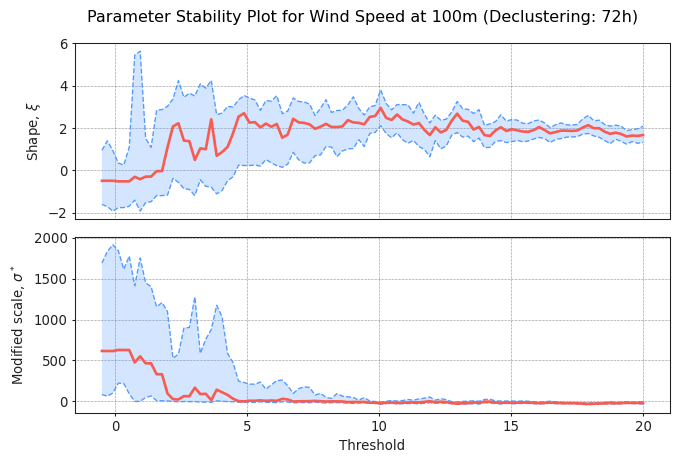

In [6]:
#Plotting the parameter stability plot for a declustering time of 72h
from pyextremes import plot_parameter_stability
plot_parameter_stability(data, 
                         thresholds = np.linspace(-0.5, 20, 100), 
                         r = "72H",
                         alpha = 0.95)
plt.suptitle('Parameter Stability Plot for Wind Speed at 100m (Declustering: 72h)', y=0.95)
plt.show()

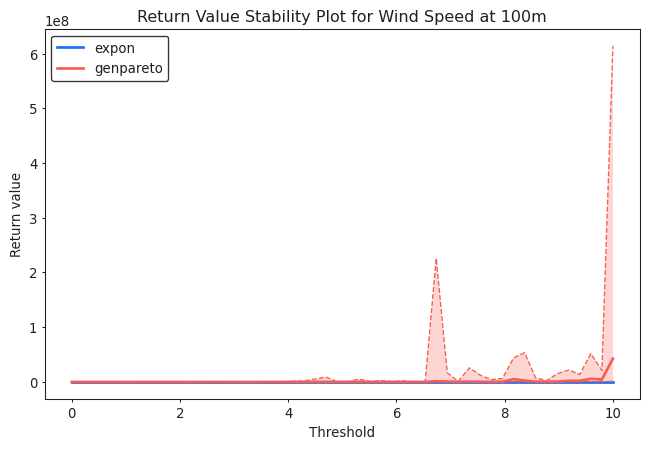

In [7]:
from pyextremes import plot_return_value_stability

plot_return_value_stability(
    data,
    return_period=100,
    thresholds=np.linspace(0, 10, 50),
    alpha=0.95,
)
plt.title('Return Value Stability Plot for Wind Speed at 100m')
plt.show()


c:\Users\joppe\miniconda3\envs\mude-base\Lib\site-packages\pyextremes\eva.py:131: RuntimeWarning: 4,678 Null values found in `data` - removing invalid entries
  warnings.warn(message=message, category=RuntimeWarning)
c:\Users\joppe\miniconda3\envs\mude-base\Lib\site-packages\pyextremes\extremes\peaks_over_threshold.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  r = pd.to_timedelta(r)
c:\Users\joppe\miniconda3\envs\mude-base\Lib\site-packages\pyextremes\eva.py:525: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  self.__extremes_kwargs["r"] = pd.to_timedelta(kwargs.get("r", "24h"))
c:\Users\joppe\miniconda3\envs\mude-base\Lib\site-packages\pyextremes\extremes\peaks_over_threshold.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  r = pd.to_timedelta(r)


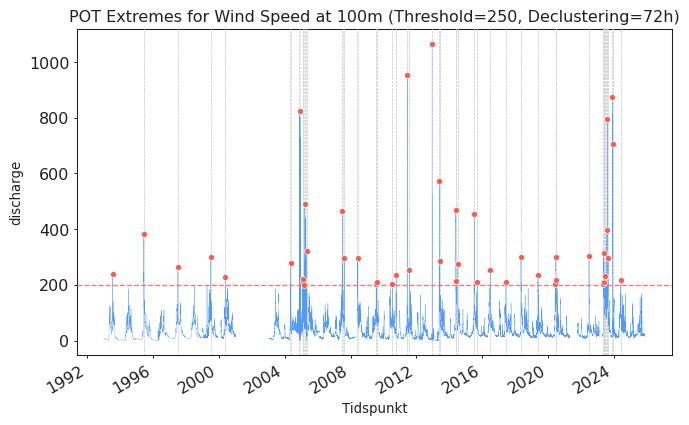

The extremes constitute 0.02% of the total data points.


In [8]:
# Ensure the data is in the correct format for EVA
# The input should be a pandas Series with a datetime index
  # Assuming 'data' is a pandas Series with a datetime index
model = EVA(data=data)
model.get_extremes(
    method="POT",
    extremes_type="high",
    threshold = 200, 
    r = "72H")
#Plotting them
plot_extremes(
    ts=data,
    extremes = model.extremes,
    extremes_method="POT",
    extremes_type="high",
    threshold=200,
    r="72H",
)
plt.title('POT Extremes for Wind Speed at 100m (Threshold=250, Declustering=72h)')
plt.xticks(fontsize=12)

plt.yticks(fontsize=12)
plt.show();
# Calculate the percentage of extremes compared to the total data points
percentage_extremes = (len(model.extremes) / len(data)) * 100                                           ## Brpn vinden voor bepaling Threshold

print(f"The extremes constitute {percentage_extremes:.2f}% of the total data points.")

In [9]:
#Fitting the distribution and printing the fitting features
model.fit_model(
    model = "MLE",
    distribution = "genpareto")
print(model.model)

# Print the number of extremes identified
print(f"Number of extremes identified: {len(model.extremes)}")

              MLE model               
--------------------------------------
free parameters: c=0.641, scale=74.249
fixed parameters: floc=200.000        
AIC: 575.311                          
loglikelihood: -285.522               
return value cache size: 0            
fit parameter cache size: 0           
--------------------------------------
Number of extremes identified: 48


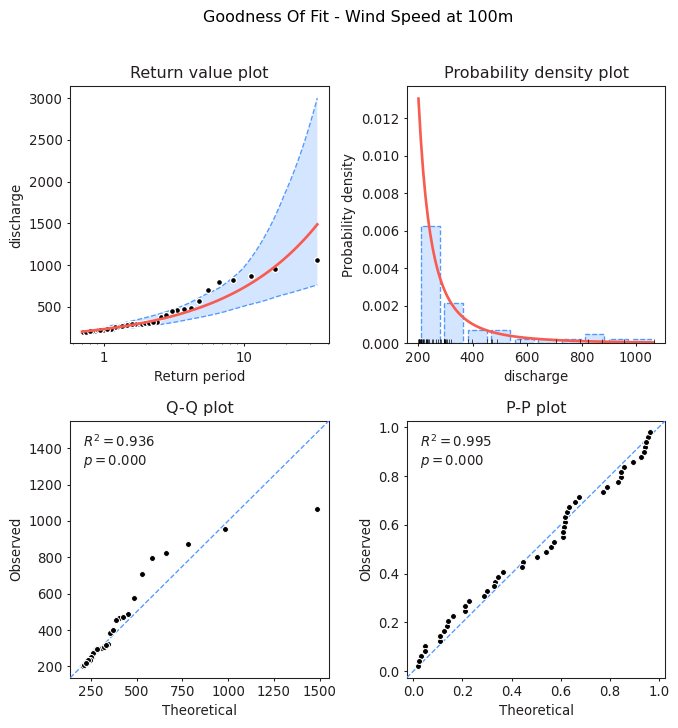

In [10]:
#Assessing goodness of fit
model.plot_diagnostic(alpha=0.95)
plt.suptitle('Goodness Of Fit - Wind Speed at 100m')
plt.show()



C:\Users\joppe\AppData\Local\Temp\ipykernel_12320\3089914185.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 100)


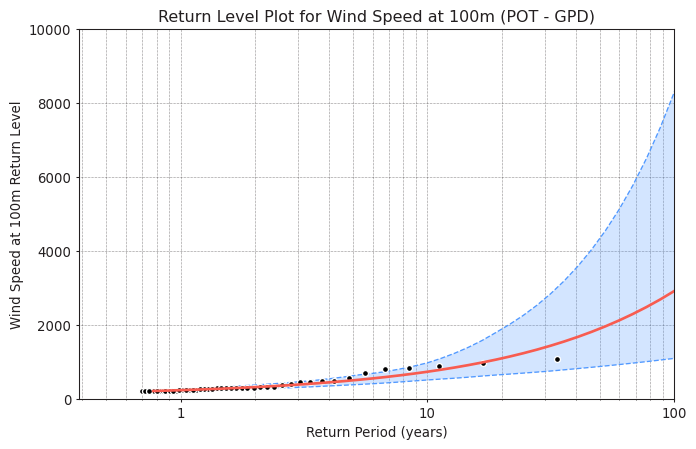

The 100-year return level for wind speed at 10m is 1090.96 m/s with a 95% confidence interval of (2909.20, 8274.32) m/s.


In [ ]:
model.plot_return_values(
    return_period=np.logspace(-0.5, 5, 100),
    return_period_size="365.2425D",
    alpha=0.95,
    )
plt.title('Return Level Plot for Wind Speed at 100m (POT - GPD)', fontsize=12)
plt.xlabel('Return Period (years)')
plt.ylabel('Wind Speed at 100m Return Level')

plt.xlim(0, 100)
plt.ylim(0, 10000)
plt.show();

# Extract the return level and confidence intervals for a 100-year return period
return_period = 100
return_level = model.get_return_value(return_period=return_period, return_period_size="365.2425D", alpha=0.95)
print(f'The 100-year return level for discharge is {return_level[1]:.2f} m^3/s with a 95% confidence interval of ({return_level[0]:.2f}, {return_level[2]:.2f}) m^3/s.')


In [12]:
print("Done")

Done
